# Stochastic Uncertainty Around the LSTM Forecast

A point forecast gives one expected future yield curve. A probabilistic forecast asks: what are plausible yield curves around that point forecast?

This notebook uses validation residuals to build a simple uncertainty model and then reads the saved Monte Carlo outputs.

## Key terms

- **Residual**: actual change minus predicted change.
- **Variance**: how spread out one maturity's errors are.
- **Covariance**: how two maturities' errors move together.
- **Covariance matrix**: a table containing all variances and covariances across maturities.
- **Multivariate normal distribution**: a probability model that samples several related variables at once.
- **Point forecast**: one best estimate.
- **Probabilistic forecast**: a range of plausible outcomes around the point estimate.

## Assumptions

This is intentionally simple. It assumes validation residuals are representative of near-future errors, residuals are centered at zero, errors are approximately multivariate normal, and the covariance matrix is stable for this one-step forecast.

In [1]:
# ruff: noqa: E402, I001
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SUMMARY_PATH = PROJECT_ROOT / "results" / "uncertainty_summary.json"
SCENARIO_PATH = PROJECT_ROOT / "results" / "monte_carlo_yield_curves.csv"
RANGE_PATH = PROJECT_ROOT / "reports" / "tables" / "uncertainty_ranges.csv"
FAN_FIGURE = PROJECT_ROOT / "reports" / "figures" / "yield_curve_fan.png"
RANGE_FIGURE = (
    PROJECT_ROOT / "reports" / "figures" / "uncertainty_ranges_by_maturity.png"
)

## Load saved uncertainty outputs

The simulation generated approximately 1,000 future yield curves and saved confidence ranges by maturity.

In [2]:
summary = json.loads(SUMMARY_PATH.read_text())
scenarios = pd.read_csv(SCENARIO_PATH)
ranges = pd.read_csv(RANGE_PATH)
{
    "latest_input_date": summary["latest_input_date"],
    "scenario_count": summary["scenario_count"],
    "residual_source": summary["residual_source"],
    "scenario_table_shape": scenarios.shape,
}

{'latest_input_date': '2026-09-08',
 'scenario_count': 1000,
 'residual_source': 'validation split only',
 'scenario_table_shape': (1000, 8)}

## Residual covariance matrix

This matrix is estimated from validation residuals only. Values are in squared basis-point units. Larger diagonal values mean that maturity has more forecast-error variance. Positive off-diagonal values mean errors tend to move together.

In [3]:
maturities = list(summary["point_forecast_yields_percent"].keys())
covariance = pd.DataFrame(
    summary["residual_covariance_basis_points"],
    index=maturities,
    columns=maturities,
)
covariance

,3M,6M,1Y,2Y,5Y,10Y,30Y
3M,6.189675,3.290292,2.388734,2.374550,2.249902,2.061744,1.694766
6M,3.290292,4.919477,3.457719,3.674274,3.979084,3.469047,3.232558
1Y,2.388734,3.457719,6.251426,5.940426,6.575505,5.245386,4.934735
2Y,2.374550,3.674274,5.940426,12.137893,12.823008,10.955217,9.894094
5Y,2.249902,3.979084,6.575505,12.823008,17.841222,16.470231,15.299167
10Y,2.061744,3.469047,5.245386,10.955217,16.470231,19.645652,18.453845
30Y,1.694766,3.232558,4.934735,9.894094,15.299167,18.453845,21.164993


## Yield-curve fan

The fan chart shows the neural point forecast plus Monte Carlo uncertainty bands. Wider bands mean more uncertainty.

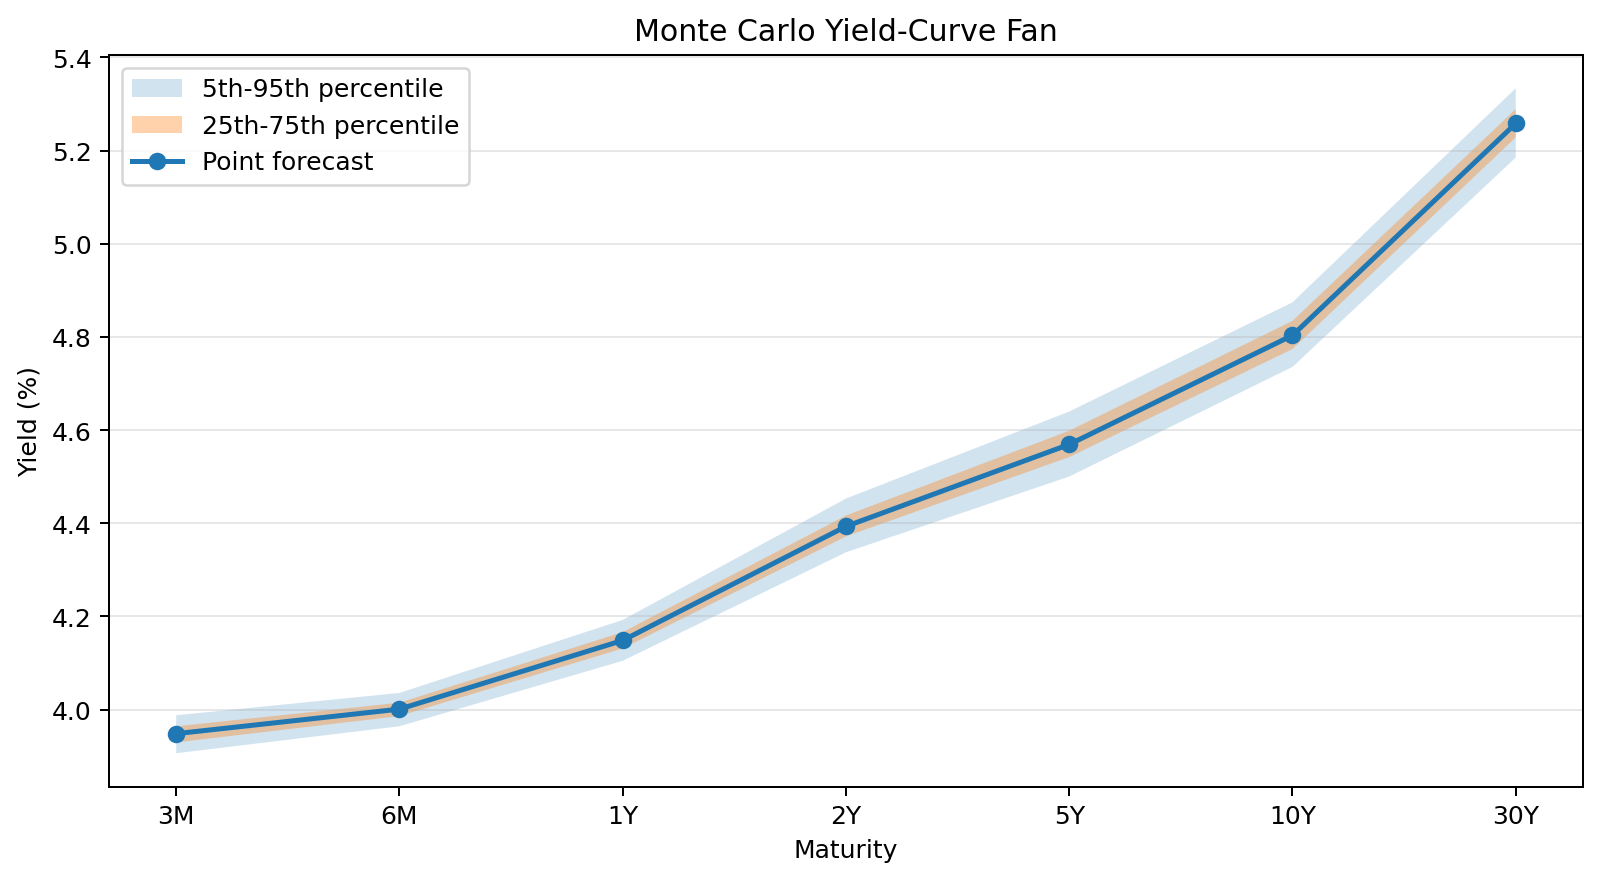

In [4]:
display(Image(filename=FAN_FIGURE))

## Confidence ranges by maturity

The table shows the 5th, 50th, and 95th percentile simulated yield levels. The 90% width is shown in basis points.

In [5]:
ranges

,maturity,point_forecast_yield_percent,p05_yield_percent,p50_yield_percent,p95_yield_percent,width_90pct_bp
0,3M,3.948482,3.906422,3.947021,3.987993,8.157107
1,6M,4.001157,3.964347,3.999954,4.035919,7.157176
2,1Y,4.148597,4.104871,4.147735,4.192679,8.780773
3,2Y,4.393418,4.337763,4.393917,4.453126,11.536339
4,5Y,4.569318,4.500418,4.568915,4.639882,13.946400
5,10Y,4.803478,4.735658,4.802890,4.874373,13.871584
6,30Y,5.258275,5.185143,5.257942,5.333836,14.869325


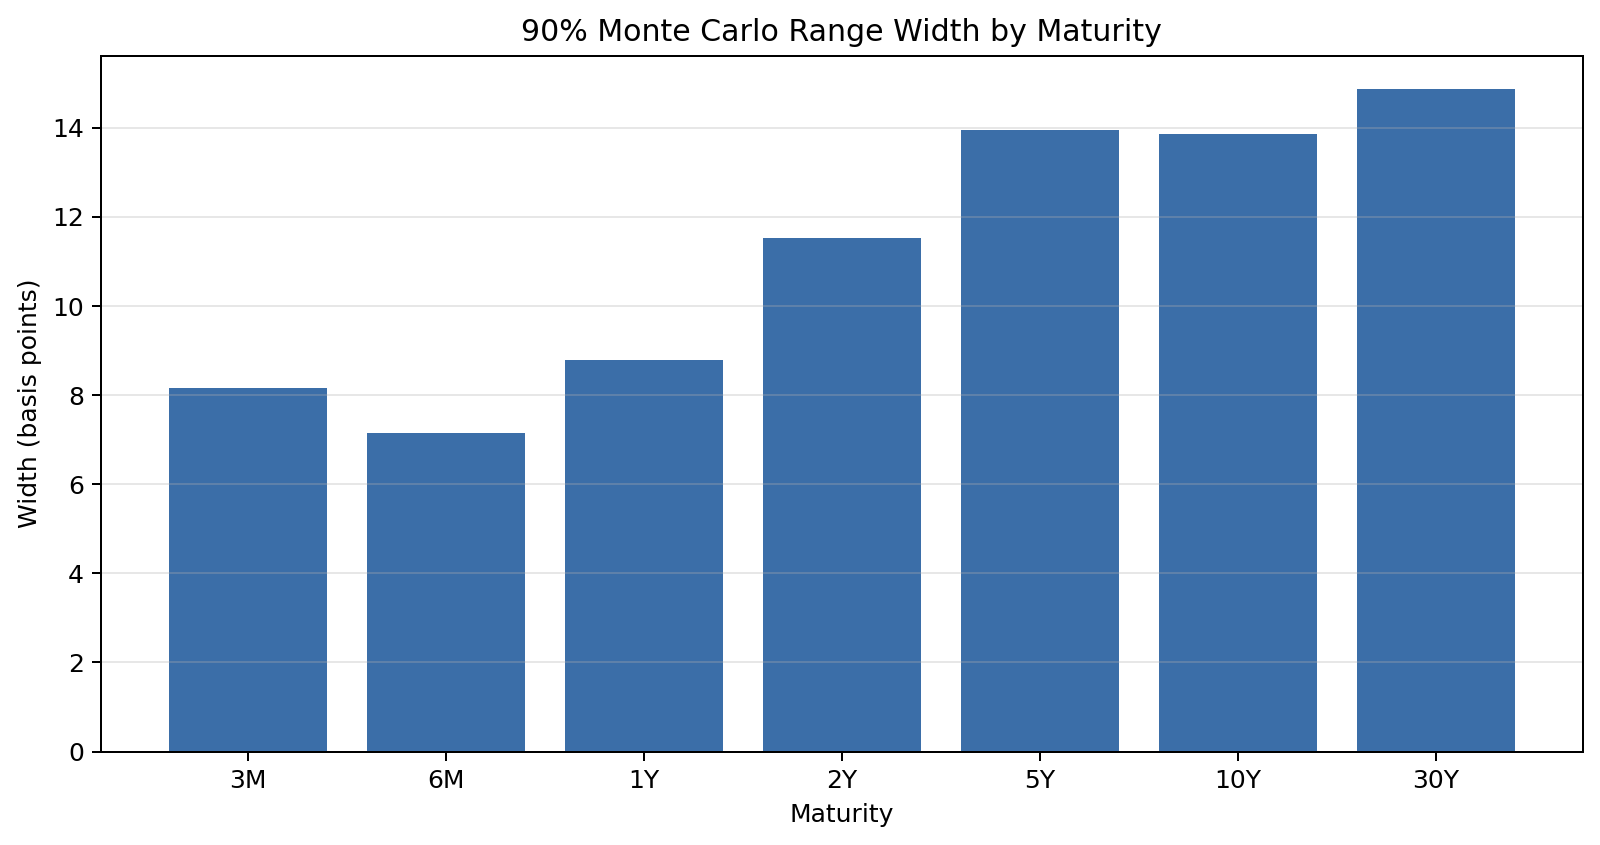

In [6]:
display(Image(filename=RANGE_FIGURE))

## Example simulated curves

Each row is one simulated future yield curve. The first column is just the scenario number.

In [7]:
scenarios.head(10)

,scenario,3M,6M,1Y,2Y,5Y,10Y,30Y
0,1,3.956191,4.045308,4.156789,4.378816,4.555371,4.788586,5.234685
1,2,3.934544,3.997501,4.164992,4.409979,4.591643,4.799718,5.274533
2,3,3.975417,4.001355,4.142396,4.393933,4.549691,4.776322,5.230263
3,4,3.935038,3.986038,4.140956,4.396710,4.600319,4.845569,5.297244
4,5,3.970042,4.014657,4.120670,4.350800,4.539370,4.795585,5.265284
5,6,3.941847,3.970920,4.130031,4.371748,4.537517,4.750062,5.200088
6,7,3.953213,3.999824,4.159470,4.409739,4.595948,4.824515,5.297763
7,8,3.961770,3.999546,4.123321,4.387837,4.561780,4.814669,5.255595
8,9,3.898514,3.994273,4.140694,4.382900,4.585212,4.830437,5.278246
9,10,3.948530,3.985421,4.129901,4.354037,4.539305,4.795128,5.244166


## Interpretation

This is a lightweight uncertainty estimate, not a full market risk engine. Its value is that it turns one forecast into a range of plausible curves while preserving the observed cross-maturity error structure from validation residuals.